In [1]:
import os
from dotenv import load_dotenv
from IPython.display import display, Image

def view_graph(app):
    return display(Image(app.get_graph().draw_mermaid_png()))

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY not found — check that .env exists and defines it.")

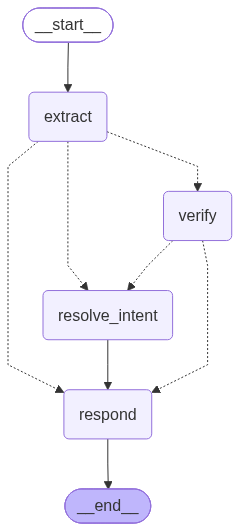

In [3]:
from graph import build_graph

app = build_graph()

view_graph(app)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict, Sequence, Literal, Optional
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

    phase: Literal['VERIFY_ID', 'RESOLVE_INTENT', 'PROCESS_CASE', 'POST_PROCESS']

    party_id: Optional[str]
    claimed: dict
    verified: bool
    gate: dict

class Verification(BaseModel):
    """Identity values heard in the caller's latest message.
 
    Every field is optional. A caller almost never supplies all of them at
    once, and a required field would force the model to invent a value.
    """
    full_name: Optional[str] = Field(
        None, description="Full name of the caller as spoken. Do not correct "
        "the spelling or guess at a different name."
    )
    dob: Optional[str] = Field(
        None, description="Date of birth as YYYY-MM-DD. Convert whatever format "
        "the caller used into that. '15th of March 1985' -> '1985-03-15'. "
        "Two-digit years before 30 are 20xx, otherwise 19xx. If the date is "
        "genuinely ambiguous, return it unchanged rather than guessing."
    )
    phone: Optional[str] = Field(
        None, description="Phone as digits only, no spaces, dashes, parentheses "
        "or country code. '(650) 521-2836' -> '6505212836'."
    )
    email: Optional[str] = Field(
        None, description="Email address, lowercase. Expand spoken forms: "
        "'margaret at email dot com' -> 'margaret@email.com'."
    )
    id_last4: Optional[str] = Field(
        None,
        description="Last 4 digits of SSN or national ID, as a 4-character "
        "string. Keep leading zeros: '0472' not 472.",
    )
    policy_number: Optional[str] = Field(
        None, description="Policy number such as POL-9921"
    )
 

In [ ]:
def extract(state:AgentState) -> AgentState:
    """Extract the verification claims"""
    

In [ ]:
graph = StateGraph(AgentState)

graph.add_node(START,)